# 02. Hydrogen Oxidation Reaction

The hydrogen oxidation reaction uses the Volmer–Heyrovsky–Tafel mechanism of
notebook 01 without modification. The steps remain written cathodic-forward and
we scan $\eta>0$, where the Butler–Volmer factors favor the reverse (anodic) rates. The net cycle then runs in reverse, and the current is positive.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import core          # parameterized microkinetics engine (the methods)
import mechanisms as M   # the mechanisms and designed-RLS cases of the paper

## The mechanism and the paper's HOR cases

`M.HOR_CASES` holds the four anodic-branch parameter sets used in the paper's
HOR figure: Volmer, Heyrovsky, and Tafel, each tuned so that the named step
controls the anodic current, and Parallel, in which Heyrovsky, Tafel, and
Volmer co-control the current and no single step is rate-limiting. The methods
are demonstrated on the Heyrovsky case first.

In [2]:
mech = M.her_mechanism(**M.HOR_CASES["Heyrovsky"])
print("species:", mech.species)
print("steps:  ", mech.labels, " (cathodic-written; scanned at eta > 0)")
for name, kw in M.HOR_CASES.items():
    print(f"{name:>10}: {kw}")

species: ['*', 'H']
steps:   ['Volmer', 'Heyrovsky', 'Tafel']  (cathodic-written; scanned at eta > 0)
    Volmer: {'k1': 1e-06, 'km1': 0.001, 'k2': 1000.0, 'km2': 1.0, 'k3': 1e-06, 'km3': 1e-12}
 Heyrovsky: {'k1': 1.0, 'km1': 1.0, 'k2': 0.001, 'km2': 0.001, 'k3': 1e-06, 'km3': 1e-06}
     Tafel: {'k1': 1.0, 'km1': 100.0, 'k2': 1e-08, 'km2': 1e-10, 'k3': 1.0, 'km3': 0.0001}
  Parallel: {'k1': 0.03, 'km1': 0.03, 'k2': 1.0, 'km2': 1.0, 'k3': 1.0, 'km3': 1.0}


## Numerical integration to steady state

The coverage equations are integrated from a clean surface until they settle.
The steady-state current, the coverages, and a central-difference local Tafel
slope are reported.

In [3]:
etas_coarse = np.linspace(0.01, 0.60, 12)
eta_n, j_n, th_n, b_n = core.numerical_scan(mech, etas_coarse)

print(f"{'eta/V':>8}{'j/A cm^-2':>14}{'b/mV dec^-1':>13}   coverages")
for e, jj, th, b in zip(eta_n, j_n, th_n, b_n):
    cov = "  ".join(f"{s}={t:6.3f}" for s, t in zip(mech.species, th))
    print(f"{e:8.3f}{jj:14.3e}{b:13.1f}   {cov}")

   eta/V     j/A cm^-2  b/mV dec^-1   coverages
   0.010     7.554e-08         20.7   *= 0.596  H= 0.404
   0.064     6.094e-07         99.9   *= 0.922  H= 0.078
   0.117     1.869e-06        115.9   *= 0.989  H= 0.011
   0.171     5.358e-06        118.0   *= 0.998  H= 0.002
   0.225     1.523e-05        118.3   *= 0.999  H= 0.001
   0.278     4.327e-05        118.3   *= 0.999  H= 0.001
   0.332     1.229e-04        118.3   *= 0.999  H= 0.001
   0.385     3.490e-04        118.3   *= 0.999  H= 0.001
   0.439     9.911e-04        118.3   *= 0.999  H= 0.001
   0.493     2.815e-03        118.3   *= 0.999  H= 0.001
   0.546     7.994e-03        118.3   *= 0.999  H= 0.001
   0.600     2.270e-02        118.3   *= 0.999  H= 0.001


## Quasi-steady-state approximation

The same steady state is obtained by solving $N\,v(\theta)=0$ with a root
finder, seeded by continuation from the previous overpotential, which is fast
enough for a dense grid.

In [4]:
etas_dense = np.linspace(0.01, 0.60, 160)
eta_q, j_q, th_q, b_q = core.qssa_scan(mech, etas_dense)

# agreement at the coarse points (QSSA evaluated exactly there)
j_q_at = np.array([core.qssa_state(mech, e)[0] for e in eta_n])
print("max relative |j_QSSA - j_num| at the coarse points:",
      np.max(np.abs((j_q_at - j_n) / j_n)))

max relative |j_QSSA - j_num| at the coarse points: 2.18790066438855e-16


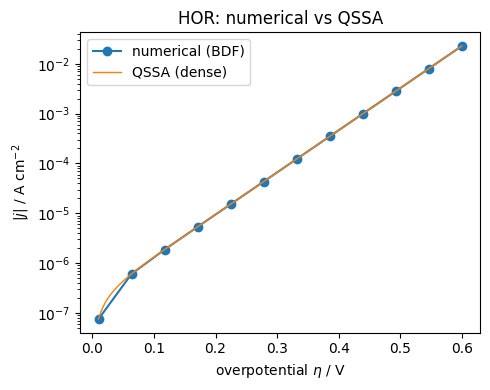

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_n, np.abs(j_n), "o-", label="numerical (BDF)")
ax.semilogy(eta_q, np.abs(j_q), "-", lw=1, label="QSSA (dense)")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HOR: numerical vs QSSA")
fig.tight_layout(); plt.show()

## Stochastic simulation (Gillespie Monte Carlo)

The stochastic method abandons the mean-field description: $N$ discrete sites
with integer occupancies, advanced one elementary event at a time by the direct
Gillespie algorithm. The trajectory-averaged current converges to the
deterministic value, with a standard error estimated from independent
trajectories. Light settings and a few overpotentials are used here so the cell
completes in seconds. The error bars tighten as `n_sites`, the event budget,
and `n_traj` are increased.

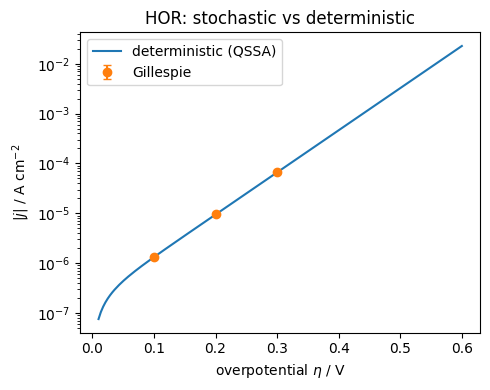

eta=+0.100 V   j= 1.312e-06 +/- 1.7e-09 A/cm^2
eta=+0.200 V   j= 9.503e-06 +/- 3.0e-08 A/cm^2
eta=+0.300 V   j= 6.591e-05 +/- 1.4e-07 A/cm^2


In [6]:
etas_gmc = np.array([0.10, 0.20, 0.30])
eg, jg, seg, thg = core.gillespie_scan(mech, etas_gmc,
                                       n_sites=1000, n_burn=20000, n_prod=80000, n_traj=3)

fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_q, np.abs(j_q), "-", label="deterministic (QSSA)")
ax.errorbar(eg, np.abs(jg), yerr=seg, fmt="o", capsize=3, label="Gillespie")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HOR: stochastic vs deterministic")
fig.tight_layout(); plt.show()

for e, jj, s in zip(eg, jg, seg):
    print(f"eta={e:+.3f} V   j={jj: .3e} +/- {s:.1e} A/cm^2")

## Potentiostatic transients

The same probe as in notebook 01, on the anodic side: the potential is stepped
up from a clean surface and the current relaxes as the H coverage approaches
its steady state.

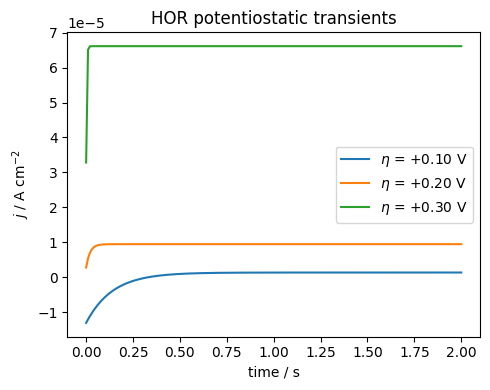

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
for e in (0.10, 0.20, 0.30):
    t, it = core.transient(mech, e, t_end=2.0, n=200)
    ax.plot(t, it, label=fr"$\eta$ = {e:+.2f} V")
ax.set_xlabel("time / s"); ax.set_ylabel(r"$j$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HOR potentiostatic transients")
fig.tight_layout(); plt.show()

## Four designed landscapes

The polarization and local-slope curves for the four cases. The
Tafel-controlled case saturates: its chemical RLS carries no potential
dependence, so the current approaches a plateau and $b\to\infty$. The Parallel
case, although controlled by no single step, produces a smooth Tafel response.

In [8]:
cases = {name: core.qssa_scan(M.her_mechanism(**kw), etas_dense)
         for name, kw in M.HOR_CASES.items()}

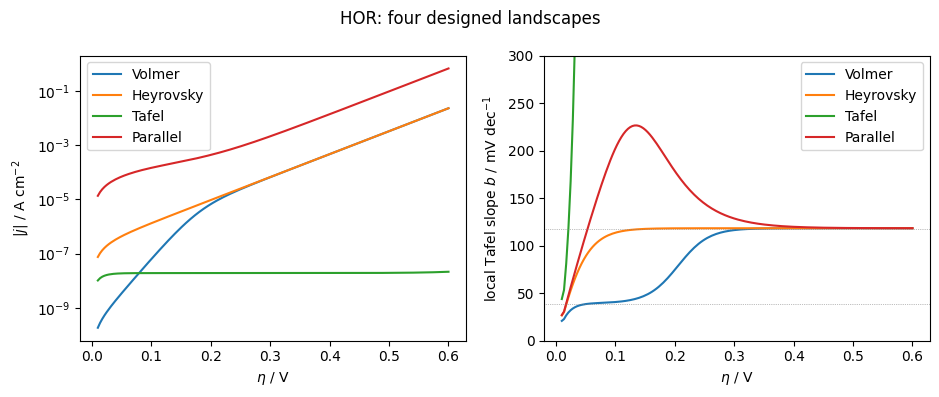

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
for name, (ee, jj, _, _) in cases.items():
    ax1.semilogy(ee, np.abs(jj), label=name)
    ax2.plot(ee, M.local_slope(ee, jj), label=name)
ax1.set_xlabel(r"$\eta$ / V"); ax1.set_ylabel(r"$|j|$ / A cm$^{-2}$"); ax1.legend()
ax2.set_xlabel(r"$\eta$ / V"); ax2.set_ylabel(r"local Tafel slope $b$ / mV dec$^{-1}$")
ax2.set_ylim(0, 300); ax2.axhline(118, color="gray", lw=0.5, ls=":")
ax2.axhline(39, color="gray", lw=0.5, ls=":")
ax2.legend(); fig.suptitle("HOR: four designed landscapes")
fig.tight_layout(); plt.show()

In [10]:
def slope_at(ee, jj, eta0):
    b = M.local_slope(ee, jj)
    return b[np.argmin(np.abs(ee - eta0))]

print(f"{'case':>12}{'b @ +0.05 V':>14}{'b @ +0.40 V':>14}   (mV/dec)")
for name, (ee, jj, _, _) in cases.items():
    b1, b2 = slope_at(ee, jj, 0.05), slope_at(ee, jj, 0.40)
    fmt = lambda b: f"{b:10.1f}" if b < 1e3 else "     >1000"
    print(f"{name:>12}{fmt(b1):>14}{fmt(b2):>14}")

        case   b @ +0.05 V   b @ +0.40 V   (mV/dec)
      Volmer          38.6         118.3
   Heyrovsky          89.5         118.3
       Tafel         >1000         >1000
    Parallel         112.5         119.8


## Summary

On the anodic branch the same three-step mechanism produces saturating,
$\approx 120$ mV/dec, and window-dependent slopes depending on the landscape,
and the co-controlled Parallel case yields a line with no single
RLS behind it. The Tafel slope is a property of the coupled cycle, not of an
individual step.